In [1]:
ML_DATA_PATH = './../data/ml_data.csv'
ML_DATA_TRAIN_PATH = './../data/ml_data_train.csv'
ML_DATA_VAL_PATH = './../data/ml_data_val.csv'
ML_DATA_TEST_PATH = './../data/ml_data_test.csv'
ML_WEIGHTS_PATH = './../utils/initial_pos_weights.json'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger

In [2]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913, initial_pos = False, final_pos=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102, initial_pos = False, final_pos=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447, initial_pos = False, final_pos=True)

In [3]:
def create_model(input_shape):
    inputs = Input(shape=input_shape)

    x1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.2)(x1)
    
    x2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.2)(x2)
    
    x3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.2)(x3)

    xtop = Flatten()(x3)
    xtop = Dense(256, activation='sigmoid')(xtop)
    xtop = Dropout(0.2)(xtop)
    xtop = Dense(128, activation='sigmoid')(xtop)
    xtop = Dropout(0.2)(xtop)

    predictions = Dense(64, activation='softmax')(xtop)

    model = Model(inputs=inputs, outputs=predictions)
    return model

In [ ]:
INPUT_SHAPE = (8, 8, 6)
model_1 = create_model(INPUT_SHAPE)

In [ ]:
model_1.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 5000)

In [ ]:
history = model_1.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
873/873 [==============================] - 12s 8ms/step - loss: 3.5152 - accuracy: 0.1584 - val_loss: 3.4267 - val_accuracy: 0.1583
Epoch 2/20
873/873 [==============================] - 7s 8ms/step - loss: 3.3872 - accuracy: 0.1694 - val_loss: 3.3206 - val_accuracy: 0.1767
Epoch 3/20
873/873 [==============================] - 6s 7ms/step - loss: 3.3231 - accuracy: 0.1755 - val_loss: 3.2615 - val_accuracy: 0.1750
Epoch 4/20
873/873 [==============================] - 7s 8ms/step - loss: 3.2676 - accuracy: 0.1869 - val_loss: 3.2132 - val_accuracy: 0.1931
Epoch 5/20
873/873 [==============================] - 7s 8ms/step - loss: 3.2244 - accuracy: 0.1899 - val_loss: 3.1755 - val_accuracy: 0.1970
Epoch 6/20
873/873 [==============================] - 6s 7ms/step - loss: 3.1752 - accuracy: 0.1967 - val_loss: 3.1451 - val_accuracy: 0.2079
Epoch 7/20
873/873 [==============================] - 7s 8ms/step - loss: 3.1554 - accuracy: 0.2013 - val_loss: 3.1284 - val_accuracy: 0.2047
Epoch

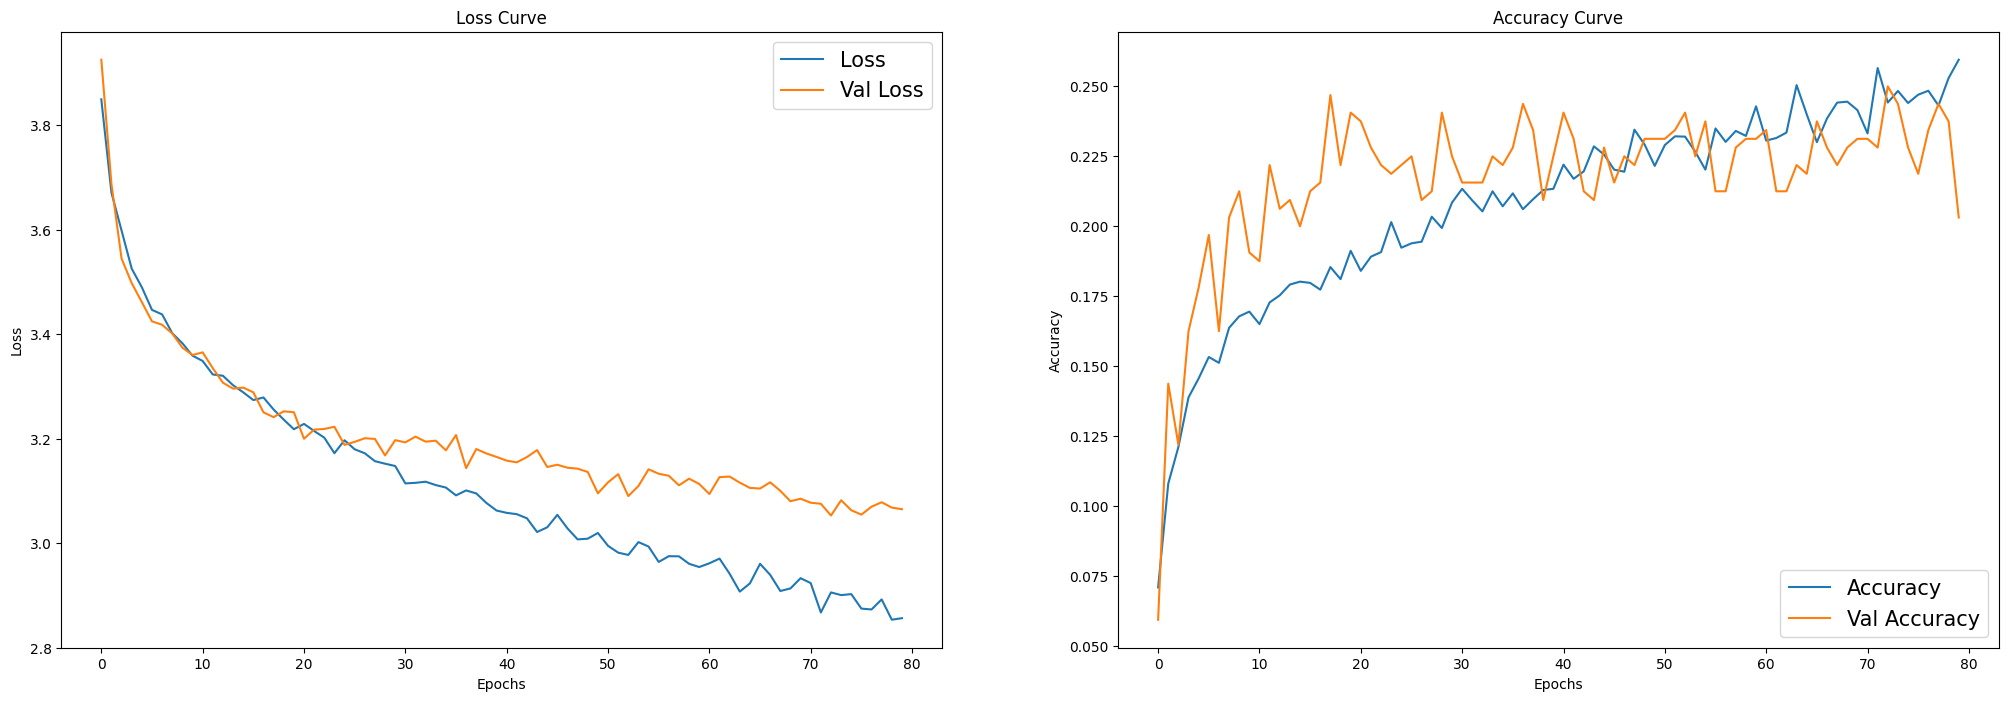

In [11]:
plot_graph(history=stepwise_logger)

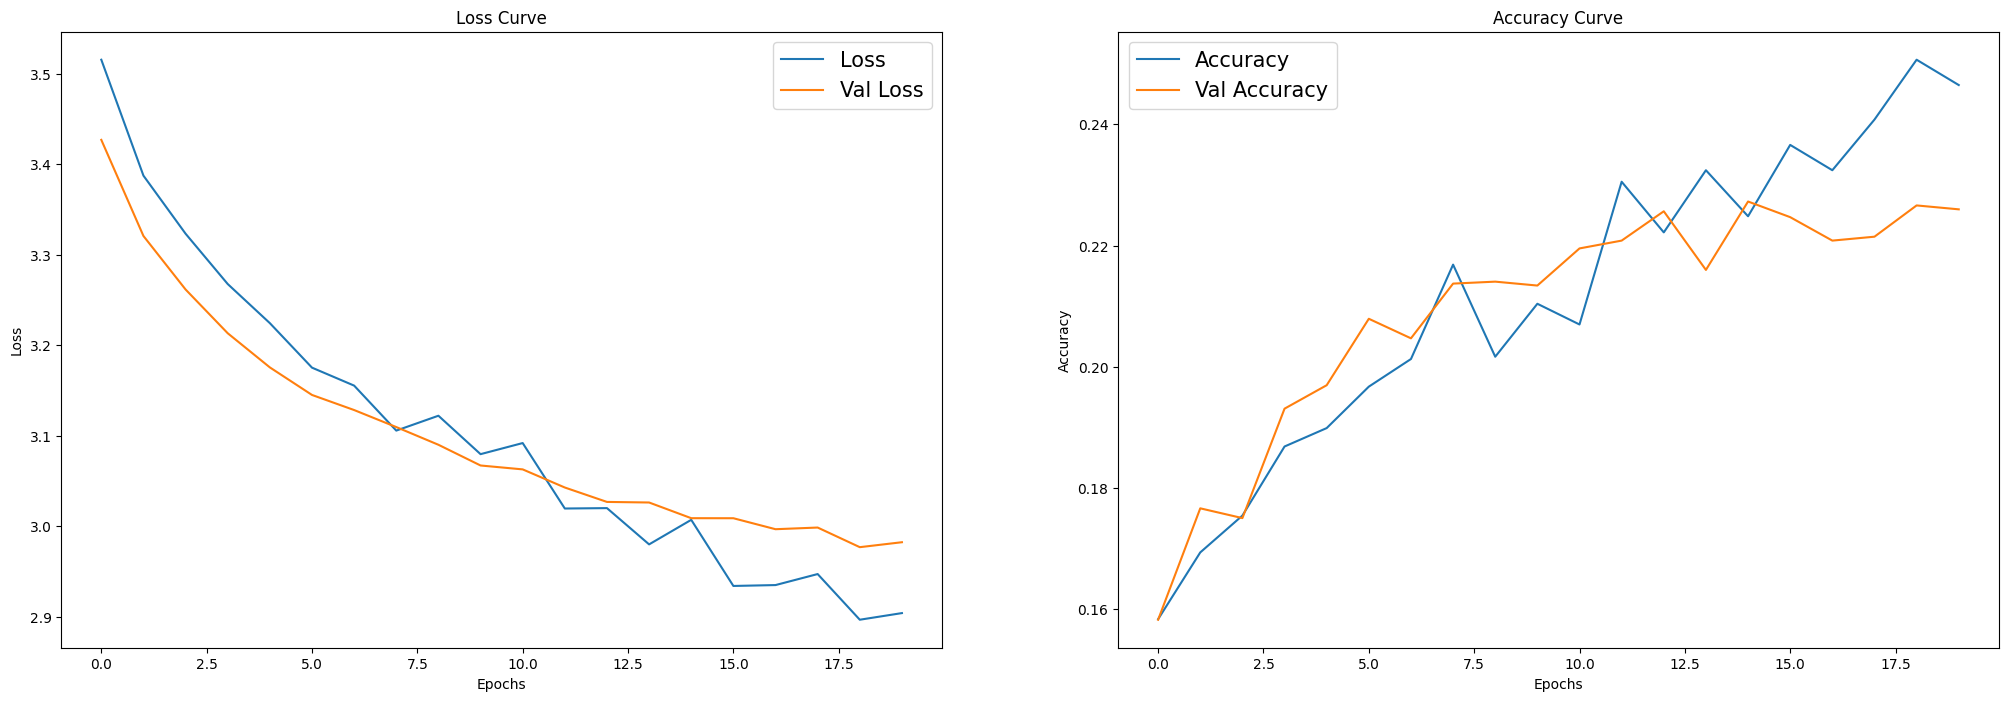

In [12]:
plot_graph(history=history)

In [13]:
model_1.evaluate(test_data_generator)

108/108 [==============================] - 1s 5ms/step - loss: 2.9625 - accuracy: 0.2466


[2.9625279903411865, 0.2465912401676178]

# Ahora teniendo en cuenta la pieza de entrada

In [69]:
def create_model_concat(input_shape):
    inputs = Input(shape=input_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(inputs)
    cnn1 = BatchNormalization()(cnn1)
    cnn1 = Dropout(0.2)(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    cnn2 = Dropout(0.2)(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)
    cnn3 = Dropout(0.2)(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_initial_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)
    mlp_initial_pos = Dense(128, activation='sigmoid')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='softmax', name = 'initial_pos')(mlp_initial_pos)
    
    combined_features = Concatenate()([latent_space, initial_pos_preds])

    mlp_final_pos = Dense(256, activation='sigmoid')(combined_features)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_final_pos = Dense(128, activation='sigmoid')(mlp_final_pos)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='softmax', name = 'final_pos')(mlp_final_pos)

    model = Model(inputs=inputs, outputs=[initial_pos_preds, final_pos_preds])
    return model

In [70]:
model_2 = create_model_concat(INPUT_SHAPE)
model_2.summary()

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d_45 (Conv2D)             (None, 8, 8, 8)      440         ['input_12[0][0]']               
                                                                                                  
 batch_normalization_45 (BatchN  (None, 8, 8, 8)     32          ['conv2d_45[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 dropout_83 (Dropout)           (None, 8, 8, 8)      0           ['batch_normalization_45[0]

In [71]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913, initial_pos = True, final_pos=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102, initial_pos = True, final_pos=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447, initial_pos = True, final_pos=True)

In [72]:
model_2.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 200)

In [73]:
history = model_2.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
873/873 [==============================] - 10s 10ms/step - loss: 6.4642 - initial_pos_loss: 2.9644 - final_pos_loss: 3.4999 - initial_pos_accuracy: 0.2351 - final_pos_accuracy: 0.1474 - val_loss: 6.3410 - val_initial_pos_loss: 2.8842 - val_final_pos_loss: 3.4568 - val_initial_pos_accuracy: 0.2447 - val_final_pos_accuracy: 0.1641
Epoch 2/20
873/873 [==============================] - 9s 10ms/step - loss: 6.0809 - initial_pos_loss: 2.7110 - final_pos_loss: 3.3699 - initial_pos_accuracy: 0.2685 - final_pos_accuracy: 0.1755 - val_loss: 5.9020 - val_initial_pos_loss: 2.5890 - val_final_pos_loss: 3.3130 - val_initial_pos_accuracy: 0.2850 - val_final_pos_accuracy: 0.1799
Epoch 3/20
873/873 [==============================] - 8s 9ms/step - loss: 5.8313 - initial_pos_loss: 2.5504 - final_pos_loss: 3.2809 - initial_pos_accuracy: 0.3008 - final_pos_accuracy: 0.1739 - val_loss: 5.6384 - val_initial_pos_loss: 2.4195 - val_final_pos_loss: 3.2190 - val_initial_pos_accuracy: 0.3079 - val_fina

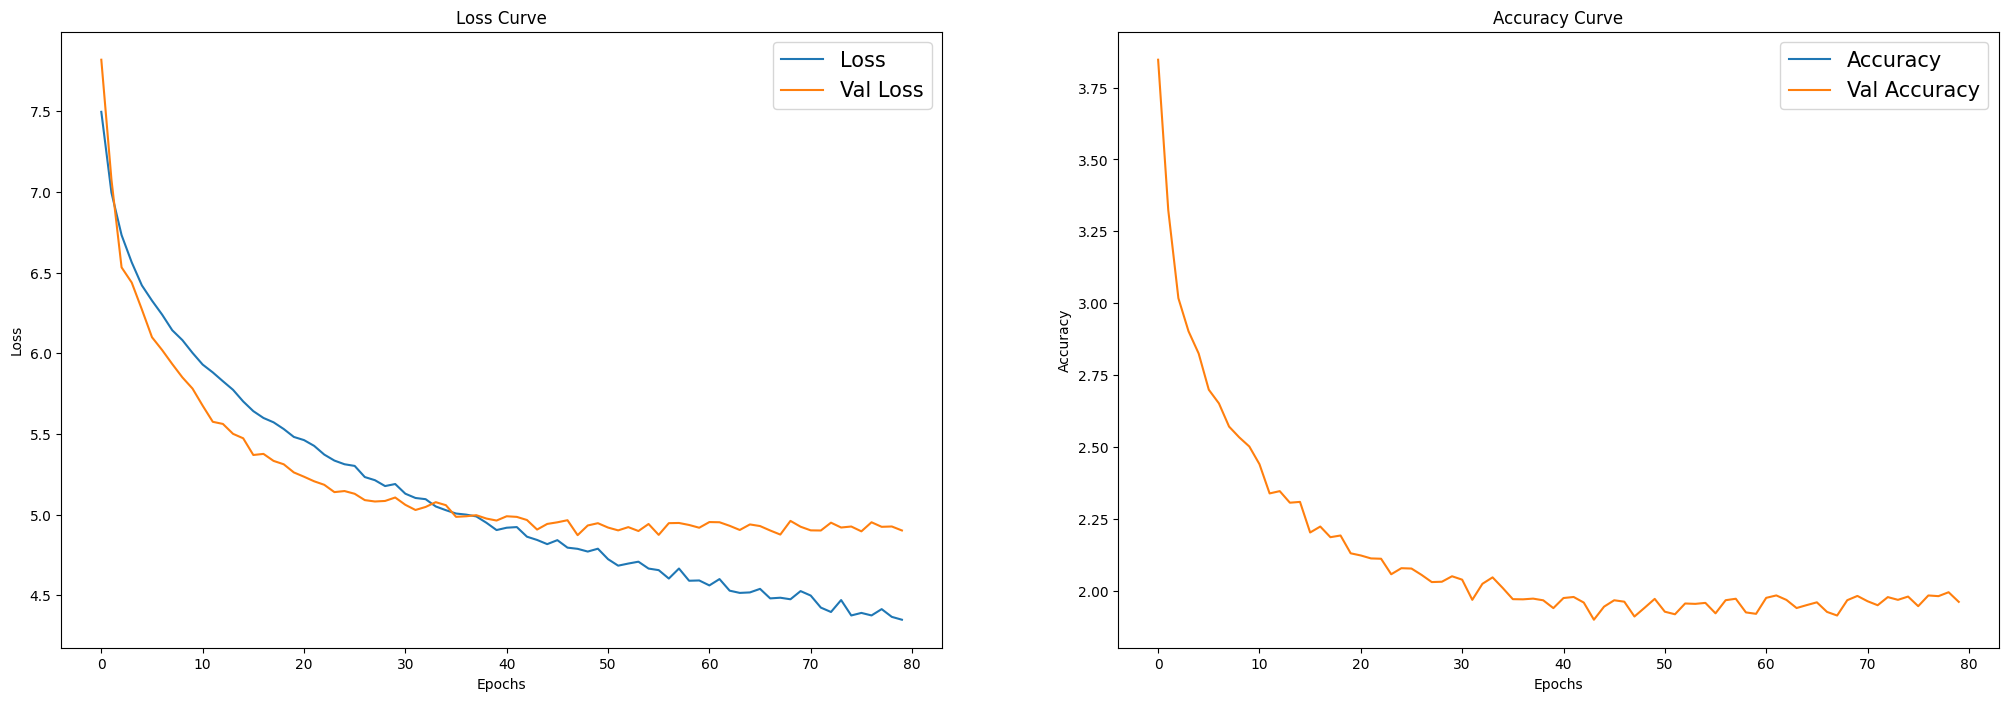

In [74]:
plot_graph(history=stepwise_logger)

KeyError: 'accuracy'

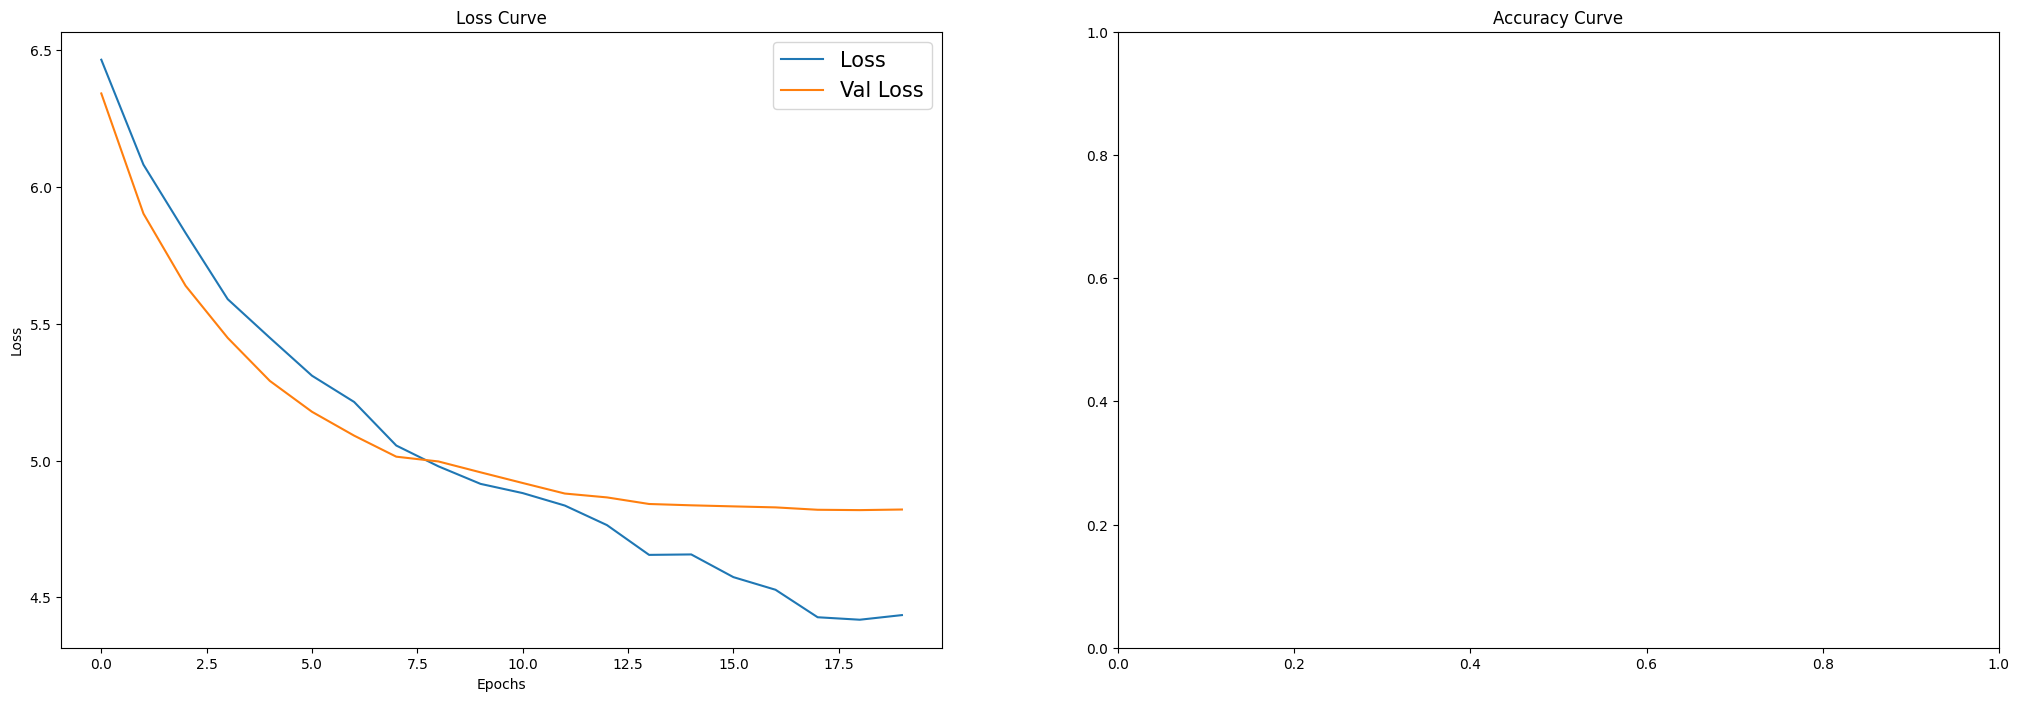

In [75]:
plot_graph(history=history)

In [ ]:
model_2.evaluate(test_data_generator)

108/108 [==============================] - 1s 5ms/step - loss: 4.8796 - initial_pos_loss: 1.9854 - final_pos_loss: 2.8942 - initial_pos_accuracy: 0.3821 - final_pos_accuracy: 0.2559


[4.8795857429504395,
 1.98543381690979,
 2.894153118133545,
 0.3820713758468628,
 0.2558746635913849]